<a href="https://colab.research.google.com/github/mamoor2019/DeepCSATScorePrediction/blob/MyRepositery/DeepCSAT_Score_Prediction_mamoor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    : E-Commerce Customer Satisfaction Score Prediction



Project Type - Deep Learning

Contribution - Individual

Team Member  - Mohammad Mamoor Ahmad

# **Project Summary -**



This project focuses on predicting **Customer Satisfaction (CSAT) scores** for an e-commerce platform, **Shopzilla**, using a **Deep Learning Artificial Neural Network (ANN)**. Customer satisfaction is an important business metric because it directly influences customer loyalty, repeat purchases, service quality, and overall business growth. The project uses customer service interaction data, including communication channels, issue categories, response times, product information, agent details, customer feedback, and transaction-related features to predict CSAT scores.

The project begins with **data cleaning and preprocessing**, including handling missing values, converting date and time fields, encoding categorical variables, and preparing numerical features for deep learning. **Feature engineering** is then performed to extract useful information such as response and handling durations from the available timestamps. These prepared features are used to develop and train an **ANN-based deep learning model** for CSAT prediction.

The model's performance is evaluated using appropriate metrics to determine how accurately it can predict customer satisfaction. The predictions are further analyzed to identify factors and patterns that may influence customer experience, helping businesses identify opportunities for improving customer service.

Finally, the trained model is **deployed locally** so that it can be used to generate customer satisfaction predictions for new customer interactions. This provides a practical demonstration of how deep learning can be applied to e-commerce customer-service data to support faster analysis, proactive service improvement, and better customer experience management.

### Key Project Components

* **Data Preparation:** Clean and preprocess customer interaction and CSAT data.
* **Feature Engineering:** Extract meaningful features from customer, order, product, agent, and time-related information.
* **Deep Learning Model:** Build and train an Artificial Neural Network to predict CSAT scores.
* **Model Evaluation:** Measure prediction performance using suitable evaluation metrics.
* **Business Insights:** Identify patterns and factors associated with customer satisfaction.
* **Local Deployment:** Deploy the trained model locally to generate CSAT predictions for new customer interactions.
* **Business Impact:** Use predicted satisfaction levels to help improve customer service quality, customer retention, and overall customer experience.


# **GitHub Link -**

https://github.com/mamoor2019/DeepCSATScorePrediction

# **Problem Statement**



Customer satisfaction is a critical factor in the success of e-commerce businesses because it influences customer loyalty, repeat purchases, customer retention, and overall business growth. However, satisfaction is commonly measured through surveys after a customer interaction has taken place. This makes it difficult for businesses to proactively identify customers who may have had an unsatisfactory experience.

The Shopzilla e-commerce platform generates large amounts of customer service interaction data, including customer feedback, issue categories, communication channels, response times, product information, order details, and agent-related information. These factors can provide valuable insights into customer experience, but analyzing their combined effect on customer satisfaction can be challenging using traditional approaches.

Therefore, this project aims to develop a **Deep Learning Artificial Neural Network (ANN) model to predict Customer Satisfaction (CSAT) scores** using historical customer interaction and service-related data. The project involves data preprocessing, feature engineering, ANN model development, model evaluation, and local deployment.

The predicted CSAT scores can help businesses better understand customer satisfaction patterns and identify opportunities to improve customer service quality and overall customer experience.


## ***1. Know Your Data***

### Import Libraries

In [1]:
 # Install required packages
!pip install tensorflow==2.20.0 keras-tuner==1.4.7 scikeras statsmodels imbalanced-learn

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, roc_curve, auc, confusion_matrix
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
import warnings

warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from scikeras.wrappers import KerasClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.7 MB/s eta 0:00:00


### Dataset Loading

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/DeepCSATScorePrediction/eCommerce_Customer_support_data.csv')

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [8]:
#  Missing Values/Null Values Count
df.isnull().sum().sort_values(ascending = False)

,0
connected_handling_time,85665
Customer_City,68828
Product_category,68711
Item_price,68701
order_date_time,68693
Customer Remarks,57165
Order_id,18232
Unique id,0
Sub-category,0
category,0


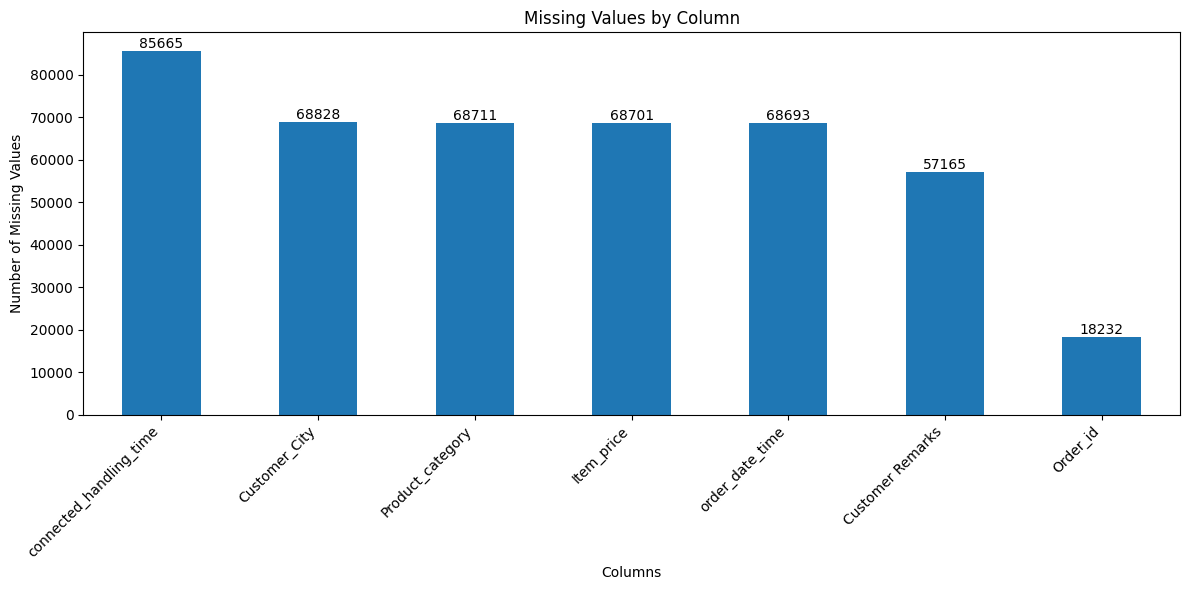

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(12, 6))
# bar chart
ax = missing_values.plot(kind='bar')

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')

# Add values on bars
for i, value in enumerate(missing_values):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains 85,907 rows and 20 columns, with no duplicate entries. However, some columns have missing values, specifically: Customer Remarks, Order_id, Order_date_time, Customer_city, Product_category, Item_price, and Connected_handling_time.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [11]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

Unique id: Unique identifier for each record (integer).

Channel name: Name of the customer service channel (object/string).

Category: Category of the interaction (object/string).

Sub-category: Sub-category of the interaction (object/string).

Customer Remarks: Feedback provided by the customer (object/string).

Order id: Identifier for the order associated with the interaction (integer).

Order date time: Date and time of the order (datetime).

Issue reported at: Timestamp when the issue was reported (datetime).

Issue responded: Timestamp when the issue was responded to (datetime).

Survey response date: Date of the customer survey response (datetime).

Customer city: City of the customer (object/string).

Product category: Category of the product (object/string).

Item price: Price of the item (float).

Connected handling time: Time taken to handle the interaction (float).

Agent name: Name of the customer service agent (object/string).

Supervisor: Name of the supervisor (object/string).

Manager: Name of the manager (object/string).

Tenure Bucket: Bucket categorizing agent tenure (object/string).

Agent Shift: Shift timing of the agent (object/string).

CSAT Score: Customer Satisfaction (CSAT) score (integer).

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
df.nunique()


,0
Unique id,85907
channel_name,3
category,12
Sub-category,57
Customer Remarks,18231
Order_id,67675
order_date_time,13766
Issue_reported at,30923
issue_responded,30262
Survey_response_Date,31


## ***3. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Bar char for distribution of Issue Categories


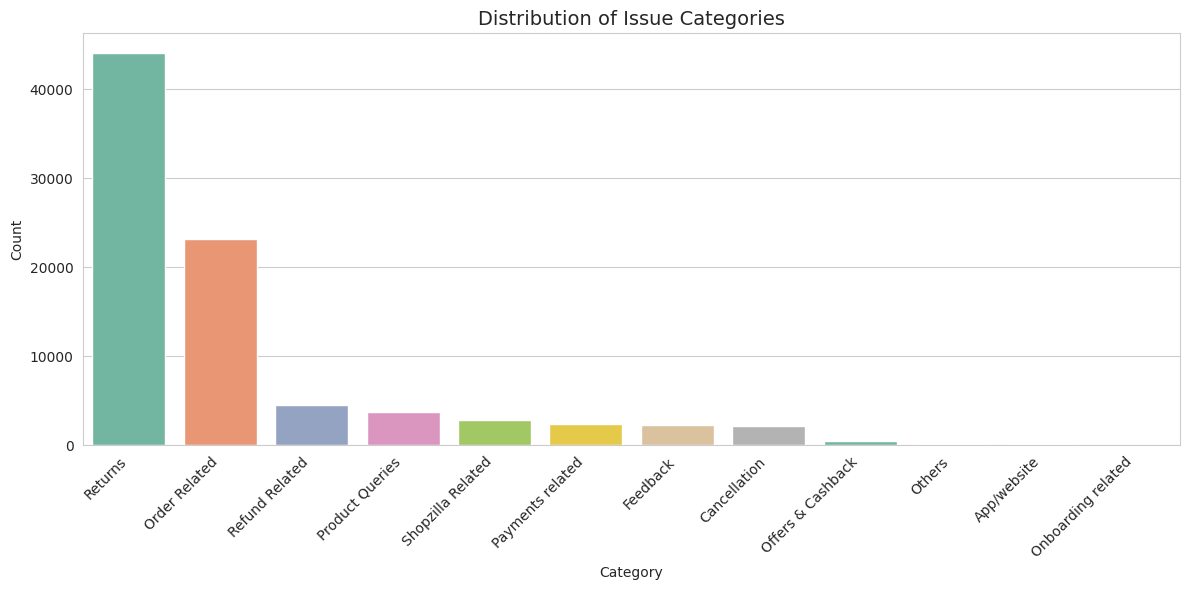

In [13]:
# Set style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
# countplot for categories
sns.countplot(
    x=df["category"],
    order=df["category"].value_counts().index,
    palette="Set2"
)

plt.title("Distribution of Issue Categories", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


What is/are the insight(s) found from the chart?

### **Insight from the Chart:**  
- **Returns and Order-Related Issues Dominate:** The majority of customer complaints are about **Returns** and **Order-Related** issues, highlighting potential inefficiencies in product return policies and order fulfillment processes.  
- **Refund and Product Queries Follow:** A significant number of customers face issues with refunds and product-related queries, suggesting the need for improved clarity in refund policies and better product information.  
- **Low Concern for Technical Issues:** Categories like **App/Website** and **Onboarding Related** have minimal complaints, indicating that technical infrastructure is relatively stable.  
- **Customer Experience Focus:** To improve satisfaction, the company should prioritize optimizing return processes, improving order management, and streamlining refund handling.

#### Chart - 2 Count plot for distribution of CSAT Scores


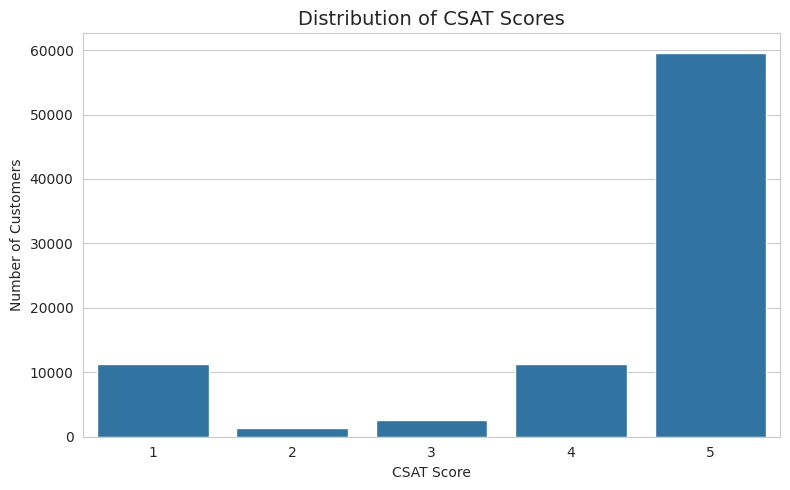

In [14]:
# plot size
plt.figure(figsize=(8, 5))
# count plot for CSAT score
sns.countplot(
    x=df["CSAT Score"],
    order=sorted(df["CSAT Score"].dropna().unique())
)

plt.title("Distribution of CSAT Scores", fontsize=14)
plt.xlabel("CSAT Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


What is/are the insight(s) found from the chart?

1. The majority of CSAT (Customer Satisfaction) scores are concentrated around **5.0**, indicating high customer satisfaction.  
2. There is a noticeable number of **low scores (1.0-1.5)**, suggesting some customers had very poor experiences.  
3. Mid-range scores (2.0-3.5) are relatively low in count, implying that customers either had extremely positive or negative experiences rather than mixed opinions.

#### Chart - 3 CSAT Score by Issue Category

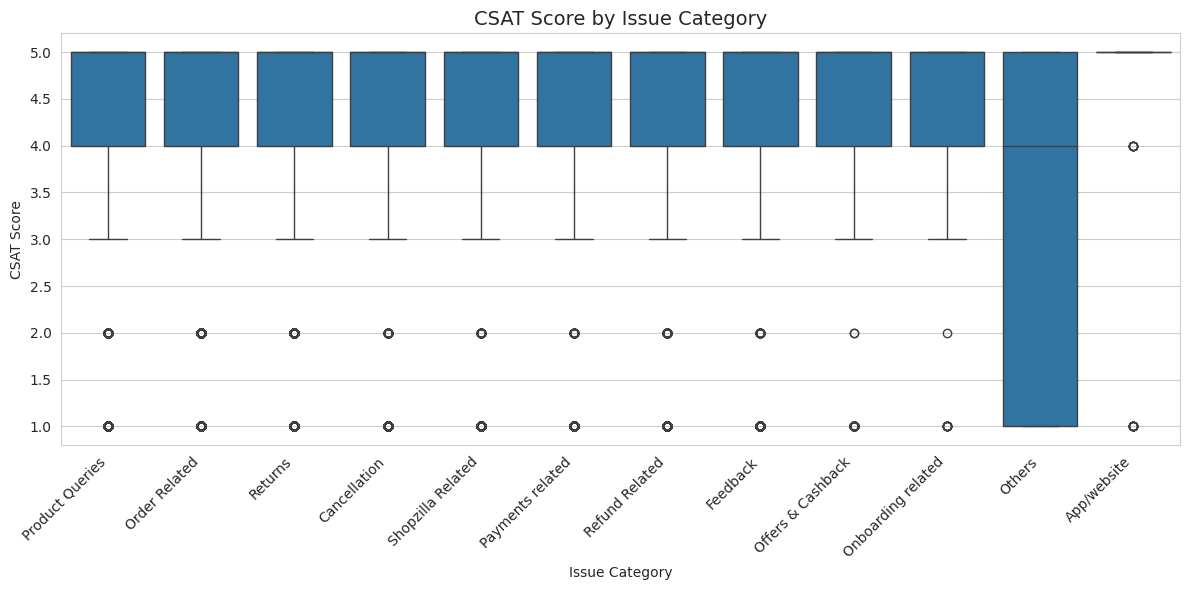

In [15]:
# plot size
plt.figure(figsize=(12, 6))
# box plot for Category and CSAT score
sns.boxplot(
    x="category",
    y="CSAT Score",
    data=df
)

plt.title("CSAT Score by Issue Category", fontsize=14)
plt.xlabel("Issue Category")
plt.ylabel("CSAT Score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Insights from the plot:
1. Most issue categories have generally high CSAT scores.
For categories such as Product Queries, Order Related, Returns, Cancellation, Shopzilla Related, Payments Related, Refund Related, Feedback, Offers & Cashback, and Onboarding Related, the main box is concentrated between 4 and 5. This indicates that a large proportion of customers in these categories gave relatively high satisfaction scores.
2. CSAT scores of 1 and 2 appear as outliers in most categories.
The individual points around 1 and 2 represent unusually low CSAT scores compared with the majority of responses. These indicate that although most customers were satisfied, some customers had very poor experiences.
3. The "Others" category has much greater variation.
The box for Others extends from approximately 1 to 5, indicating a much wider spread of CSAT scores. This suggests that customer experiences within this broad category are more varied than in the other categories.
4. The "App/Website" category appears to have very few observations.
Its box is extremely small and there are a few individual points around 1, 2, 4, and 5. This suggests that this category may have a small number of records, so conclusions about its CSAT distribution should be made cautiously.
5. The lower whisker for most categories is around 3.
This means that scores around 3 are within the normal distribution range, while scores of 1 and 2 are treated as outlying observations in these categories.

#### Chart - 4 Issue Categories by Support Channel


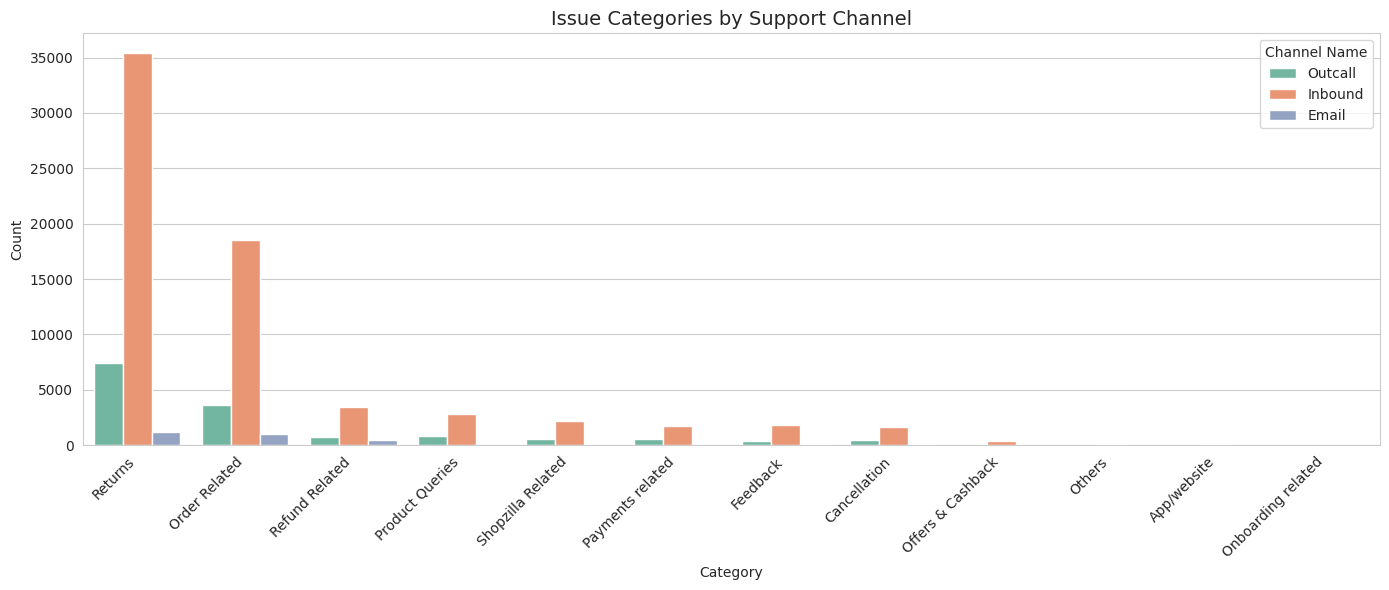

In [16]:
plt.figure(figsize=(14, 6))
#count plot for category by support channel
sns.countplot(
    x=df["category"],
    hue=df["channel_name"],
    order=df["category"].value_counts().index,
    palette="Set2"
)

plt.title("Issue Categories by Support Channel", fontsize=14)

plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Channel Name")

plt.tight_layout()
plt.show()

##### 2. What is/are the insight(s) found from the chart?

1. **Returns and Order-related issues** dominate customer support interactions, with inbound channels handling the majority.  
2. **Refund and Product Queries** are also significant, mostly managed through inbound and email channels.  
3. **Outcall support** is minimal across all issue categories, indicating a proactive approach is limited.  
4. **Offers & Cashback and App/Website issues** have very low interaction volumes, suggesting they may not be major customer concerns.

#### Chart - 5 CSAT Scores by Agent Shift


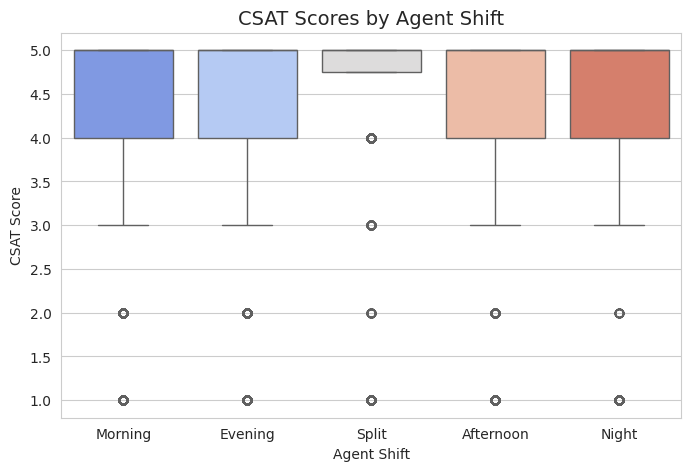

In [17]:
plt.figure(figsize=(8, 5))
# box plot for CSAT score
sns.boxplot(x=df["Agent Shift"], y=df["CSAT Score"], palette="coolwarm")
plt.title("CSAT Scores by Agent Shift", fontsize=14)
plt.xlabel("Agent Shift")
plt.ylabel("CSAT Score")
plt.show()

##### 2. What is/are the insight(s) found from the chart?

1. **CSAT scores are consistently high** across all agent shifts, with most ratings clustered around 4-5.  
2. **A few low scores (1-2)** are present in all shifts, indicating occasional dissatisfaction.  
3. **Night shift maintains high CSAT scores**, suggesting service quality is stable throughout the day.  
4. **Variability is minimal**, meaning customer satisfaction is not significantly impacted by agent shift timing.

#### Chart - 6 CSAT Scores by Agent Tenure

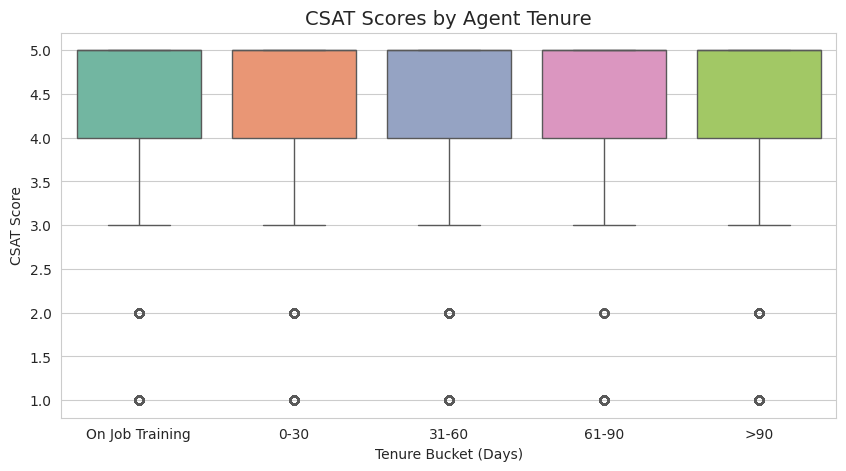

In [18]:
plt.figure(figsize=(10, 5))
# box plot to show CSAT score by agent tenure
sns.boxplot(x=df["Tenure Bucket"], y=df["CSAT Score"], order=["On Job Training", "0-30", "31-60", "61-90", ">90"], palette="Set2")
plt.title("CSAT Scores by Agent Tenure", fontsize=14)
plt.xlabel("Tenure Bucket (Days)")
plt.ylabel("CSAT Score")
plt.show()

##### 2. What is/are the insight(s) found from the chart?

1. **CSAT scores remain high across all tenure buckets**, with most ratings around 4-5.  
2. **On-the-job trainees perform similarly to experienced agents**, indicating effective training.  
3. **Low scores (1-2) are present in all tenure groups**, suggesting occasional dissatisfaction is not tenure-dependent.  
4. **Minimal variability across tenure buckets**, meaning agent experience has little impact on CSAT scores.

#### Chart - 7 Top 10 Agents Handling the Most Issues


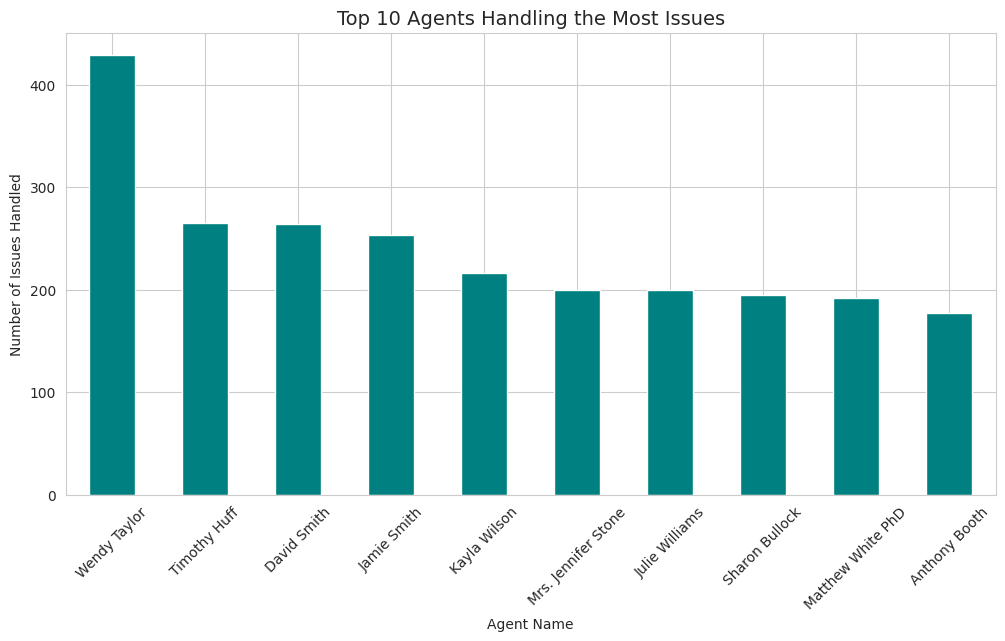

In [19]:
plt.figure(figsize=(12, 6))
df["Agent_name"].value_counts().head(10).plot(kind="bar", color="teal")
plt.title("Top 10 Agents Handling the Most Issues", fontsize=14)
plt.xlabel("Agent Name")
plt.ylabel("Number of Issues Handled")
plt.xticks(rotation=45)
plt.show()

##### 2. What is/are the insight(s) found from the chart?

1. **Wendy Taylor handles the most issues**, significantly more than others.  
2. **The next top agents handle around 260 issues**, showing a big gap from Wendy.  
3. **The last five agents have similar issue counts**, around 180.  
4. **Workload distribution is uneven**, with one agent handling nearly double the cases of others.

###Chart - 8 - Correlation Heatmap

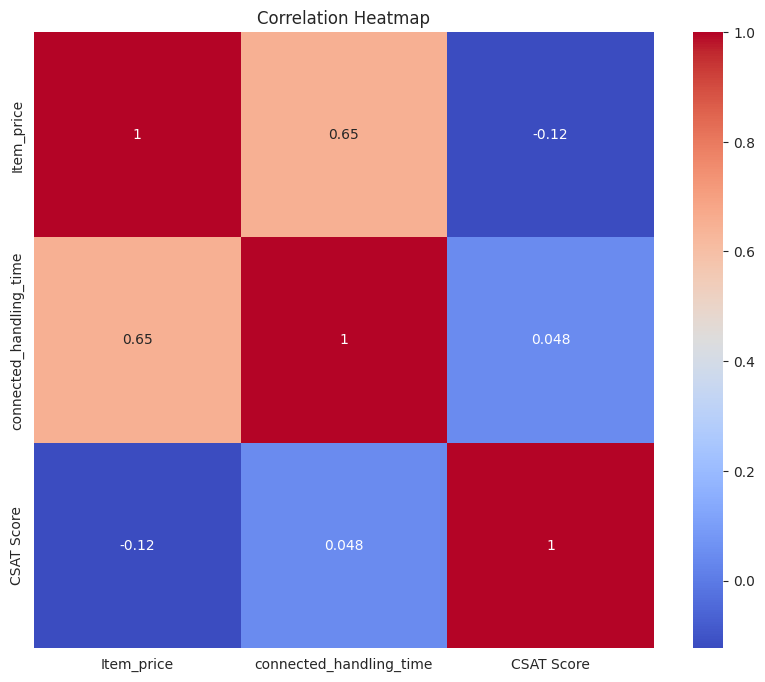

In [20]:

# Select only numeric columns for correlation calculation
numeric_data = df.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

1. **Item price and handling time have a moderate positive correlation (0.65)**—higher-priced items take longer to handle.  
2. **CSAT Score has a weak negative correlation (-0.12) with item price**, meaning expensive items slightly reduce satisfaction.  
3. **CSAT Score and handling time have a near-zero correlation (0.048)**, showing handling time doesn't strongly impact satisfaction.

###Chart - 9 - Connected Handling Time Distribution

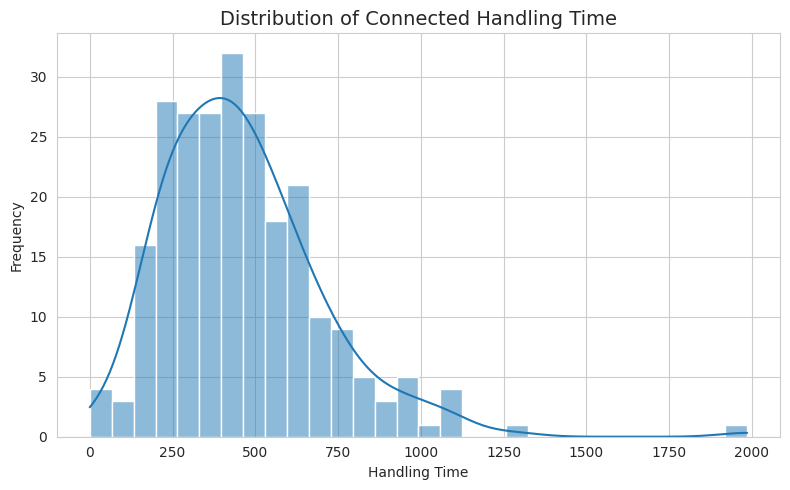

In [21]:
plt.figure(figsize=(8, 5))
# Histogram to show the connected handling time distribution
sns.histplot(
    df["connected_handling_time"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Connected Handling Time", fontsize=14)
plt.xlabel("Handling Time")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

This histogram shows the distribution of 'Connected Handling Time'. We can observe that the majority of customer interactions have shorter handling times, with the frequency decreasing as the handling time increases. This suggests that most customer issues are resolved relatively quickly.

##  **4.Feature Engineering & Data Pre-processing**

### 1. Handling Missing Values

In [22]:
df.isnull().sum().sort_values(ascending = False)

,0
connected_handling_time,85665
Customer_City,68828
Product_category,68711
Item_price,68701
order_date_time,68693
Customer Remarks,57165
Order_id,18232
Unique id,0
Sub-category,0
category,0


What all missing value imputation techniques have you used and why did you use those techniques?

I employed different missing-value handling techniques based on the nature of each feature, the proportion of missing values, and the underlying data distribution. The selected approaches were intended to preserve useful information while minimizing potential bias.

* Order ID: Since Order_id is primarily an identifier and does not provide meaningful predictive information for the analysis, and only a small number of values were missing, this column was removed from the dataset.
* Customer Remarks: This feature contained a substantial number of missing values (57,165). Rather than removing the feature, the missing entries were replaced with "Missing Reviews". This approach retained the feature while distinguishing genuinely missing remarks from available customer feedback.
* Categorical Features – Customer City and Product Category: Missing values in these important categorical variables were replaced using mode imputation. The mode, or most frequently occurring category, was selected to retain the overall distribution of the categorical variables while avoiding the loss of observations.
* Numerical Features – Connected Handling Time and Item Price: For connected_handling_time, which showed an approximately normal distribution with relatively few outliers, mean imputation was applied. For item_price, which contained more prominent outliers, median imputation was used because the median is less sensitive to extreme values.
* Order Date and Time: Missing values in order_date_time were handled using mode imputation. The resulting values were then converted to datetime format, allowing additional temporal features such as day and month to be extracted for subsequent analysis and feature engineering.

Overall, these imputation techniques were selected according to the characteristics of individual features, helping to retain valuable information, minimize data loss, and prepare the dataset for subsequent analysis and machine learning modeling.

In [23]:
# Step 1: Drop 'Order_id' column
df.drop(columns=['Order_id'], inplace=True)

# Step 2: Replace missing values in 'Customer Remarks' with 'Missing Reviews'
df['Customer Remarks'].fillna('Missing Reviews', inplace=True)

# Step 3: Impute missing values in categorical columns ('Customer city' and 'Product Category') with mode
df['Customer_City'].fillna(df['Customer_City'].mode()[0], inplace=True)
df['Product_category'].fillna(df['Product_category'].mode()[0], inplace=True)

# Step 4: Impute missing values in numerical columns ('connected_handling_time' and 'item_price')
# Impute 'connected_handling_time' with mean
df['connected_handling_time'].fillna(df['connected_handling_time'].mean(), inplace=True)
# Impute 'item_price' with median
df['Item_price'].fillna(df['Item_price'].median(), inplace=True)

# Step 5: Impute missing values in 'order_date_time' with mode
df['order_date_time'].fillna(df['order_date_time'].mode()[0], inplace=True)


# Display the first few rows of the DataFrame to verify changes
print(df.head())

                              Unique id channel_name         category  \
0  7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1  b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2  200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3  eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4  ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   

                   Sub-category Customer Remarks   order_date_time  \
0                Life Insurance  Missing Reviews  09/08/2023 11:55   
1  Product Specific Information  Missing Reviews  09/08/2023 11:55   
2             Installation/demo  Missing Reviews  09/08/2023 11:55   
3        Reverse Pickup Enquiry  Missing Reviews  09/08/2023 11:55   
4                    Not Needed  Missing Reviews  09/08/2023 11:55   

  Issue_reported at   issue_responded Survey_response_Date Customer_City  \
0  01/08/2023 11:13  01/08/2023 11:47            01-Aug-23     H

In [24]:
# Missing Values/Null Values Count
print(df.isnull().sum())

Unique id                  0
channel_name               0
category                   0
Sub-category               0
Customer Remarks           0
order_date_time            0
Issue_reported at          0
issue_responded            0
Survey_response_Date       0
Customer_City              0
Product_category           0
Item_price                 0
connected_handling_time    0
Agent_name                 0
Supervisor                 0
Manager                    0
Tenure Bucket              0
Agent Shift                0
CSAT Score                 0
dtype: int64


### 2. Handling Outliers


In [25]:
# To separate the symmetric distributed features and skew symmetric distributed features
df["CSAT Score"]=df["CSAT Score"].astype('str')
symmetric_feature=[]
non_symmetric_feature=[]
for i in df.describe().columns:
  if abs(df[i].mean()-df[i].median())<0.2:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['connected_handling_time']
Skew Symmetric Distributed Features : - ['Item_price']


In [26]:
# For Skew Symmetric features defining upper and lower boundry
def outlier_treatment(df,feature):
  upper_boundary= df[feature].mean()+3*df[feature].std()
  lower_boundary= df[feature].mean()-3*df[feature].std()
  return upper_boundary,lower_boundary

In [27]:
# Restricting the data to lower and upper boundry
for feature in non_symmetric_feature:
  df.loc[df[feature]<= outlier_treatment(df=df,feature=feature)[1], feature]=outlier_treatment(df=df,feature=feature)[1]
  df.loc[df[feature]>= outlier_treatment(df=df,feature=feature)[0], feature]=outlier_treatment(df=df,feature=feature)[0]

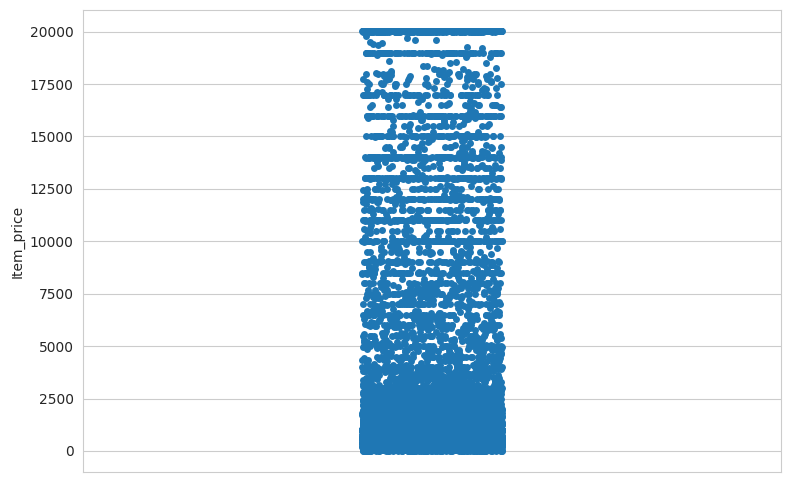

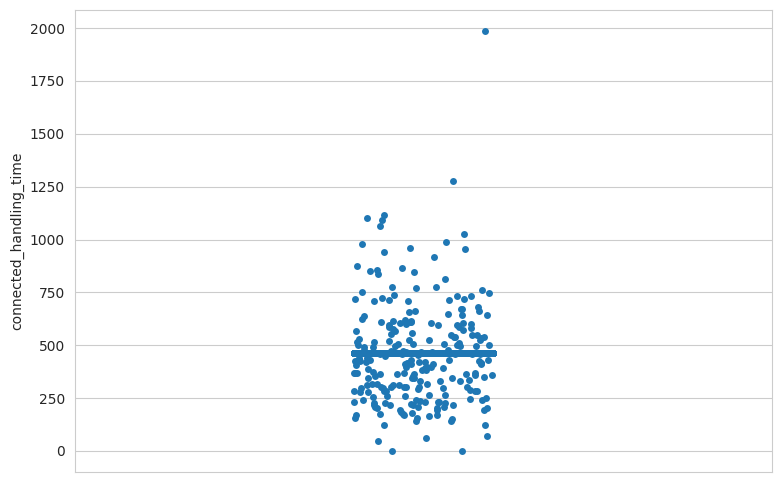

In [28]:
# After Outlier Treatment showing the dataset distribution using strip plot
# Visualising  code for the numerical columns
for col in df.describe().columns:
  fig=plt.figure(figsize=(9,6))
  sns.stripplot(df[col])

####What all outlier treatment techniques have you used and why did you use those techniques?


First, I converted the CSAT Score column from a numerical data type to a categorical variable. Although CSAT scores are represented by numbers, there are only five possible score values, so treating them as categorical classes is more appropriate for this classification problem.

Next, I separated the numerical features into symmetric and skewed distributions and applied appropriate outlier-handling techniques to each group. For the normally distributed (approximately symmetric) features, the mean and standard deviation were used to define the lower and upper boundaries for identifying extreme values.

For a Gaussian distribution, which is approximately symmetric around its mean, standard deviation provides a useful measure of the spread of the data. Values beyond the selected standard-deviation-based limits were considered extreme observations. Rather than removing these observations, I capped (winsorized) the values at the defined lower and upper boundaries. This approach reduces the influence of extreme values while retaining the original observations.

For skewed features, appropriate distribution-based boundaries were used to limit the impact of extreme observations while preserving the overall information in the dataset.

Overall, this approach helped reduce the influence of outliers, maintain the integrity of the dataset, and prepare the numerical features for subsequent machine learning modeling.

### 3. Categorical Encoding


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         85907 non-null  object 
 5   order_date_time          85907 non-null  object 
 6   Issue_reported at        85907 non-null  object 
 7   issue_responded          85907 non-null  object 
 8   Survey_response_Date     85907 non-null  object 
 9   Customer_City            85907 non-null  object 
 10  Product_category         85907 non-null  object 
 11  Item_price               85907 non-null  float64
 12  connected_handling_time  85907 non-null  float64
 13  Agent_name               85907 non-null  object 
 14  Supervisor            

In [30]:
# Removing Unique id column that do not contribute to target variable
df.drop(columns='Unique id', inplace=True)


In [31]:
# Encode categorical columns without expanding high-cardinality identifiers
# Convert "CSAT Score" to integer safely
df["CSAT Score"] = pd.to_numeric(df["CSAT Score"], errors="coerce").fillna(0).astype(int)

# Frequency-encode high-cardinality columns to avoid thousands of dummy columns
for column in ['Customer_City', 'Agent_name']:
    frequencies = df[column].value_counts(normalize=True, dropna=False)
    df[f'{column}_frequency'] = df[column].map(frequencies).astype('float32')
    df.drop(columns=[column], inplace=True)

# Identify categorical columns
categorical_columns = list(set(df.columns.to_list()).difference(set(df.describe().columns.to_list())))

# Define non-categorical columns that should be excluded
non_cat_columns = ['issue_responded', 'order_date_time', 'Issue_reported at', 'Survey_response_Date', 'Customer Remarks']

# Remove non-categorical columns from the list
categorical_columns = list(set(categorical_columns) - set(non_cat_columns))

# Print categorical columns
print("Categorical Columns are :-", categorical_columns, " :- ", len(categorical_columns))

Categorical Columns are :- ['channel_name', 'category', 'Manager', 'Tenure Bucket', 'Supervisor', 'Agent Shift', 'Product_category', 'Sub-category']  :-  8


In [32]:
# Perform one-hot encoding
df = pd.get_dummies(df, columns=categorical_columns)

# Display the encoded DataFrame
df.head()

,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Item_price,connected_handling_time,CSAT Score,Customer_City_frequency,Agent_name_frequency,...,Sub-category_Shopzilla Rewards,Sub-category_Signup Issues,Sub-category_Technician Visit,Sub-category_UnProfessional Behaviour,Sub-category_Unable to Login,Sub-category_Unable to track,Sub-category_Wallet related,Sub-category_Warranty related,Sub-category_Wrong,Sub-category_e-Gift Voucher
0,Missing Reviews,09/08/2023 11:55,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,979.0,462.400826,5,0.809596,0.000489,...,False,False,False,False,False,False,False,False,False,False
1,Missing Reviews,09/08/2023 11:55,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,979.0,462.400826,5,0.809596,0.000372,...,False,False,False,False,False,False,False,False,False,False
2,Missing Reviews,09/08/2023 11:55,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,979.0,462.400826,5,0.809596,0.000407,...,False,False,False,False,False,False,False,False,False,False
3,Missing Reviews,09/08/2023 11:55,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,979.0,462.400826,5,0.809596,0.000559,...,False,False,False,False,False,False,False,False,False,False
4,Missing Reviews,09/08/2023 11:55,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,979.0,462.400826,5,0.809596,0.001443,...,False,False,False,False,False,False,False,False,False,False


###What all categorical encoding techniques have you used & why did you use those techniques?

I have used One Hot Encoding for all the categorical features,because these features are likely nominal categorical variables, meaning there is no inherent order or ranking among the categories. For these variables, it would be appropriate to apply one-hot encoding.

## 5. Feature Manipulation & Selection


#### 5.1. Feature Manipulation


In [33]:
# remove columns Customer remarks that do not contribute to target varialbe
df = df.drop(columns=["Customer Remarks"])

In [34]:
# Manipulate Features to minimize feature correlation and create new features
# Ensure the 'Issue reported at' and 'Issue responded' columns are in datetime format
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M')
df['issue_responded'] = pd.to_datetime(df['issue_responded'], format='%d/%m/%Y %H:%M')


# Create a new feature the response time
df['Response_Time'] = df['issue_responded'] - df['Issue_reported at']

# Convert 'Response_Time' to a numerical format in seconds for aggregation
df['Response_Time_seconds'] = df['Response_Time'].dt.total_seconds()

In [35]:
# Convert order_date_time to datetime
df['order_date_time'] = pd.to_datetime(df['order_date_time'], format='%d/%m/%Y %H:%M')

# Extract day number (day of the month)
df['day_number_order_date'] = df['order_date_time'].dt.day

# Extract weekday (numerical value: 0 for Sunday, 1 for Monday, etc.)
df['weekday_num_order_date'] = df['order_date_time'].dt.weekday + 1  # Monday=1, Sunday=7


# Convert 'Survey_response_Date' to datetime format
df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date'], format='%d-%b-%y')

# Extract day number (day of the month)
df['day_number_response_date'] = df['Survey_response_Date'].dt.day

# Extract weekday (numerical value: 0 for Sunday, 1 for Monday, etc.)
df['weekday_num_response_date'] = df['Survey_response_Date'].dt.weekday + 1

In [36]:
# Drop Date columns after feature extraction
df.drop(columns=['order_date_time', 'Survey_response_Date','Issue_reported at','issue_responded','Response_Time'], inplace=True)

In [37]:
df.head()


,Item_price,connected_handling_time,CSAT Score,Customer_City_frequency,Agent_name_frequency,channel_name_Email,channel_name_Inbound,channel_name_Outcall,category_App/website,category_Cancellation,...,Sub-category_Unable to track,Sub-category_Wallet related,Sub-category_Warranty related,Sub-category_Wrong,Sub-category_e-Gift Voucher,Response_Time_seconds,day_number_order_date,weekday_num_order_date,day_number_response_date,weekday_num_response_date
0,979.0,462.400826,5,0.809596,0.000489,False,False,True,False,False,...,False,False,False,False,False,2040.0,9,3,1,2
1,979.0,462.400826,5,0.809596,0.000372,False,False,True,False,False,...,False,False,False,False,False,120.0,9,3,1,2
2,979.0,462.400826,5,0.809596,0.000407,False,True,False,False,False,...,False,False,False,False,False,1320.0,9,3,1,2
3,979.0,462.400826,5,0.809596,0.000559,False,True,False,False,False,...,False,False,False,False,False,1200.0,9,3,1,2
4,979.0,462.400826,5,0.809596,0.001443,False,True,False,False,True,...,False,False,False,False,False,120.0,9,3,1,2


Created Some new features like Response_Time_seconds, day_number_order_date, weekday_number_order_date, weekday_num_response_date and day_num_response_date

###5.2. Feature Selection



In [38]:
df.shape


(85907, 147)

In [39]:
# Dropping Constant and Quasi Constant Feature
def dropping_constant(data):
    from sklearn.feature_selection import VarianceThreshold

    # Drop non-numeric columns
    numeric_data = data.select_dtypes(include=['number'])

    var_thres = VarianceThreshold(threshold=0.05)
    var_thres.fit(numeric_data)

    concol = [column for column in numeric_data.columns
              if column not in numeric_data.columns[var_thres.get_support()]]

    if "CSAT Score" in concol:
        concol.remove("CSAT Score")

    df = data.drop(concol, axis=1)
    return df

In [40]:
# Calling the function
df=dropping_constant(df)

In [41]:
# Checking the shape after feature dropped
df.shape

(85907, 146)

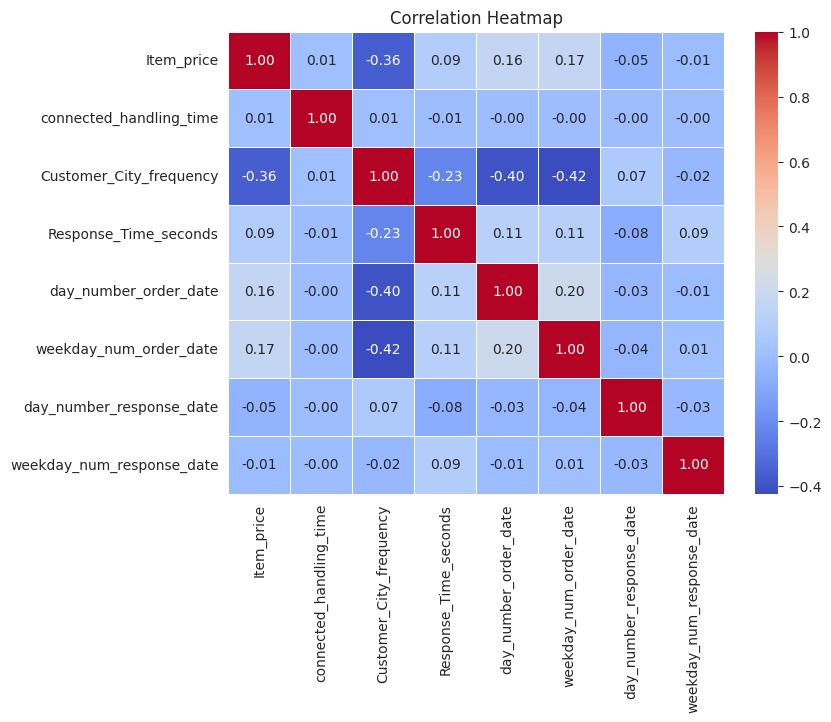

In [42]:
# Correlation Heatmap visualization code
# Drop non-numeric columns
numeric_data = df.select_dtypes(include=['number'])
numeric_data.drop(columns=['CSAT Score'], inplace=True)
corr = numeric_data.corr()
cmap = cmap=sns.diverging_palette(5, 250, as_cmap=True)



# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [43]:
# Finding The VIF scores to know which columns are highly correlated

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = numeric_data.columns
    vif_data["VIF"] = [variance_inflation_factor(numeric_data.values, i) for i in range(numeric_data.shape[1])]
    return vif_data

# Assuming df is your DataFrame containing the features
vif_results = calculate_vif(df)
print(vif_results)

                     Feature       VIF
0                 Item_price  1.154813
1    connected_handling_time  1.000127
2    Customer_City_frequency  1.581499
3      Response_Time_seconds  1.068524
4      day_number_order_date  1.191981
5     weekday_num_order_date  1.219964
6   day_number_response_date  1.009796
7  weekday_num_response_date  1.009342


In [44]:
# Drop highly correlated feature
df.drop(columns=['weekday_num_order_date'], inplace=True)

In [45]:
# Check Feature Correlation and finding multicolinearity
def correlation(df,threshold):
  col_corr=set()
  corr_matrix= df.corr()
  for i in range (len(corr_matrix.columns)):
    for j in range(i):
      if abs (corr_matrix.iloc[i,j])>threshold:
        colname=corr_matrix.columns[i]
        col_corr.add(colname)
  return list(col_corr)

In [46]:
# Getting multicolinear columns and dropping them
numeric_data = df.select_dtypes(include=['number'])
numeric_data.drop(columns=['CSAT Score'], inplace=True)
highly_correlated_columns=correlation(numeric_data,0.5)

if "CSAT Score" in highly_correlated_columns:
  highly_correlated_columns.remove("CSAT Score")
else:
  pass

df=df.drop(highly_correlated_columns,axis=1)
df.shape

(85907, 145)

In [47]:
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = numeric_data.columns
    vif_data["VIF"] = [variance_inflation_factor(numeric_data.values, i) for i in range(numeric_data.shape[1])]
    return vif_data

# Assuming df is your DataFrame containing the features
vif_results = calculate_vif(df)
print(vif_results)

                     Feature       VIF
0                 Item_price  1.154645
1    connected_handling_time  1.000123
2    Customer_City_frequency  1.386136
3      Response_Time_seconds  1.068397
4      day_number_order_date  1.190132
5   day_number_response_date  1.009743
6  weekday_num_response_date  1.009342


In [48]:
# After Feature Selection checking the shape left with
df.shape

(85907, 145)

In [49]:
df.isnull().sum()

,0
Item_price,0
connected_handling_time,0
CSAT Score,0
Customer_City_frequency,0
channel_name_Email,0
...,...
Sub-category_e-Gift Voucher,0
Response_Time_seconds,0
day_number_order_date,0
day_number_response_date,0


I used **Variance Inflation Factor (VIF)** to detect and eliminate multicollinearity in my dataset, ensuring that independent variables were not highly correlated with each other. **VIF measures how much the variance of a regression coefficient is inflated due to multicollinearity**, with higher values indicating stronger correlation among predictors. To improve model stability and interpretability, I dropped columns with high VIF scores, retaining only those with minimal redundancy while preserving meaningful insights.

###6. Data Transformation


In [50]:
# Getting symmetric and skew symmetric features from the columns
symmetric_feature=[]
non_symmetric_feature=[]
for i in df.describe().columns:
  if abs(df[i].mean()-df[i].median())<0.25:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)
# Removing Customer Service Calls column from the list as it's an important factor
# which can't be treated as outliers here will is already leading to higher churn as we have seen furing analysis.
non_symmetric_feature.remove('CSAT Score')

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['connected_handling_time', 'Customer_City_frequency', 'weekday_num_response_date']
Skew Symmetric Distributed Features : - ['Item_price', 'Response_Time_seconds', 'day_number_order_date', 'day_number_response_date']


From the features, can see that there are 4 features which aren't symmetric so aren't following gaussian distribution and rest are having symmetric curve. Thus, for those two columns I have used Exponential transformation to achieve gaussian distribution.

I tried with other transformations and found exponetial tranformation with no infinity value and working fine. So, I am continuing with Exponentiai transformation with a power of 0.25.

#### First Transformation



In [51]:
# Transform Your data
# Exponential Transforming the required column
df['Item_price']=np.sqrt(df['Item_price'])
df['Response_Time_seconds']=np.sqrt(df['Response_Time_seconds'])
df['day_number_order_date']=(df['day_number_order_date'])**0.25
df['day_number_response_date']=(df['day_number_response_date'])**0.25

In [52]:
df.isnull().sum()

,0
Item_price,0
connected_handling_time,0
CSAT Score,0
Customer_City_frequency,0
channel_name_Email,0
...,...
Sub-category_e-Gift Voucher,0
Response_Time_seconds,3128
day_number_order_date,0
day_number_response_date,0


In [53]:
#Fill NaN values with the median of Response_Time_seconds columns
df['Response_Time_seconds'] = df['Response_Time_seconds'].fillna(df['Response_Time_seconds'].median())

In [54]:
# Getting symmetric and skew symmetric features from the columns
symmetric_feature=[]
non_symmetric_feature=[]
for i in df.describe().columns:
  if abs(df[i].mean()-df[i].median())<0.25:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)
# Removing Customer Service Calls column from the list as it's an important factor
# which can't be treated as outliers here will is already leading to higher churn as we have seen furing analysis.
non_symmetric_feature.remove('CSAT Score')

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['connected_handling_time', 'Customer_City_frequency', 'day_number_order_date', 'day_number_response_date', 'weekday_num_response_date']
Skew Symmetric Distributed Features : - ['Item_price', 'Response_Time_seconds']


### Second Transformation



In [55]:
df['Response_Time_seconds'] = np.sqrt(df['Response_Time_seconds'])
df['Item_price'] = (df['Item_price'])**0.25

In [56]:
# Getting symmetric and skew symmetric features from the columns
symmetric_feature=[]
non_symmetric_feature=[]
for i in df.describe().columns:
  if abs(df[i].mean()-df[i].median())<0.25:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)
# Removing Customer Service Calls column from the list as it's an important factor
# which can't be treated as outliers here will is already leading to higher churn as we have seen furing analysis.
non_symmetric_feature.remove('CSAT Score')

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['Item_price', 'connected_handling_time', 'Customer_City_frequency', 'day_number_order_date', 'day_number_response_date', 'weekday_num_response_date']
Skew Symmetric Distributed Features : - ['Response_Time_seconds']


#### Third Transformation



In [57]:
# Perform sqrt transform on 'Response_Time_seconds' column
df['Response_Time_seconds'] = np.sqrt(df['Response_Time_seconds'])

In [58]:
# Getting symmetric and skew symmetric features from the cplumns
symmetric_feature=[]
non_symmetric_feature=[]
for i in df.describe().columns:
  if abs(df[i].mean()-df[i].median())<0.25:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)
# Removing Customer Service Calls column from the list as it's an important factor
# which can't be treated as outliers here will is already leading to higher churn as we have seen furing analysis.
non_symmetric_feature.remove('CSAT Score')

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['Item_price', 'connected_handling_time', 'Customer_City_frequency', 'Response_Time_seconds', 'day_number_order_date', 'day_number_response_date', 'weekday_num_response_date']
Skew Symmetric Distributed Features : - []


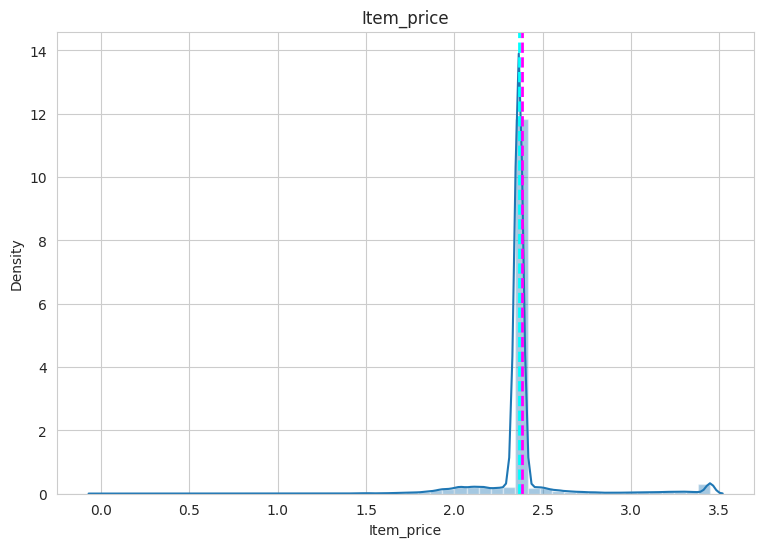

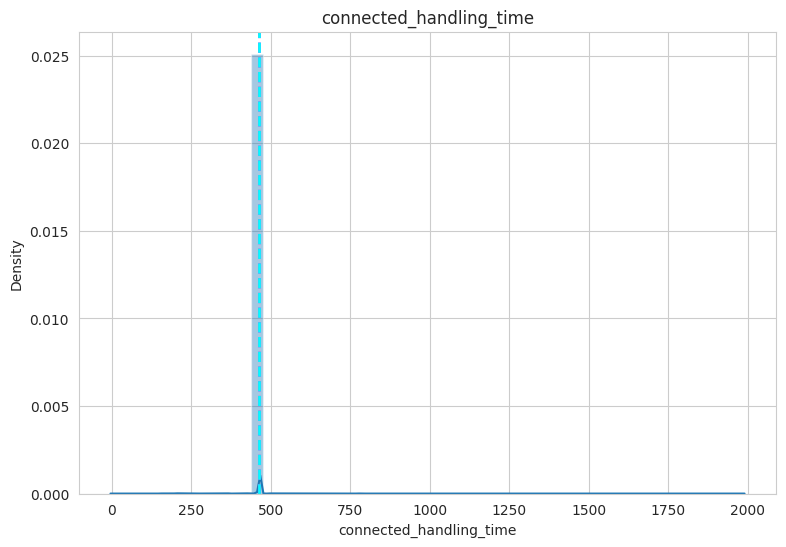

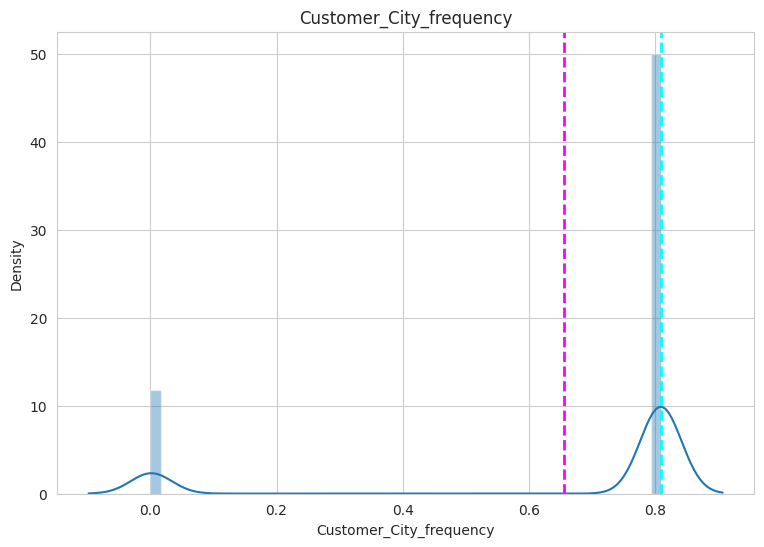

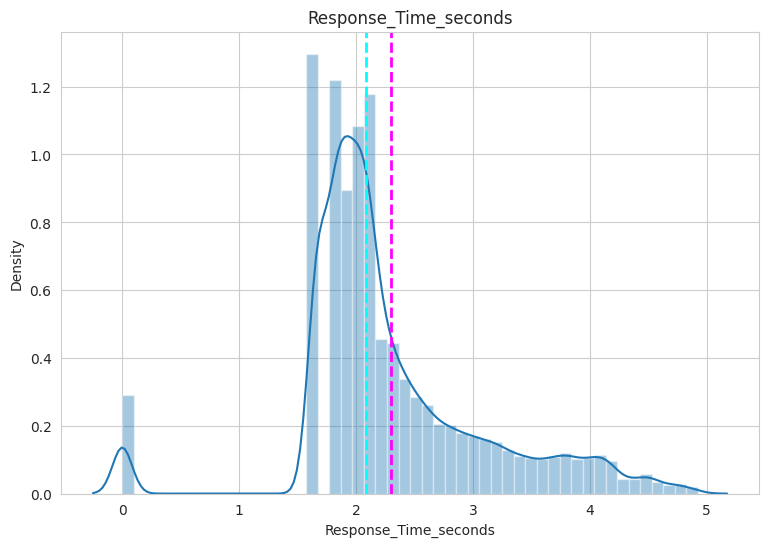

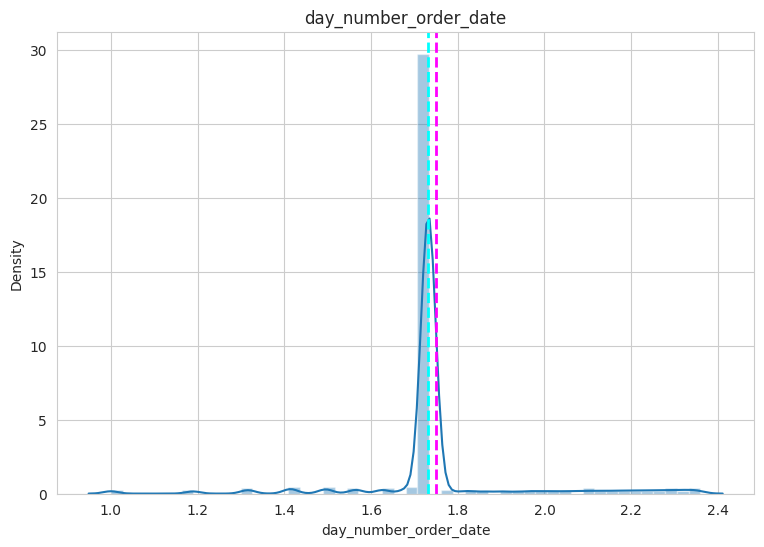

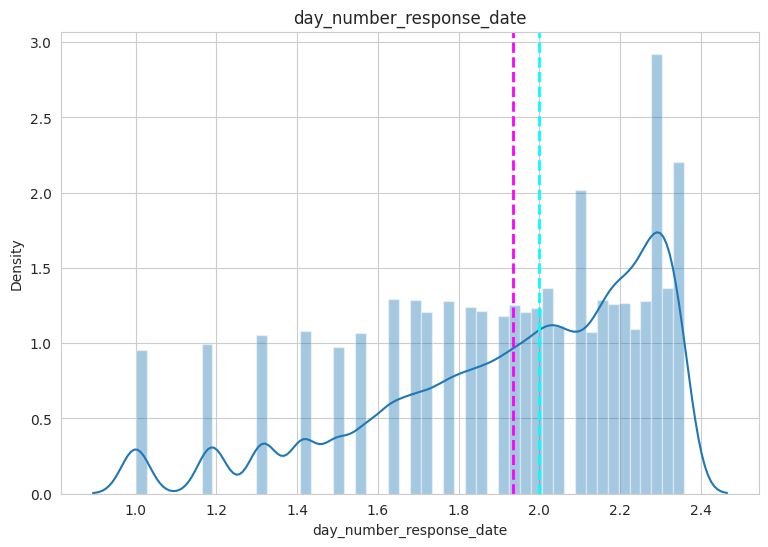

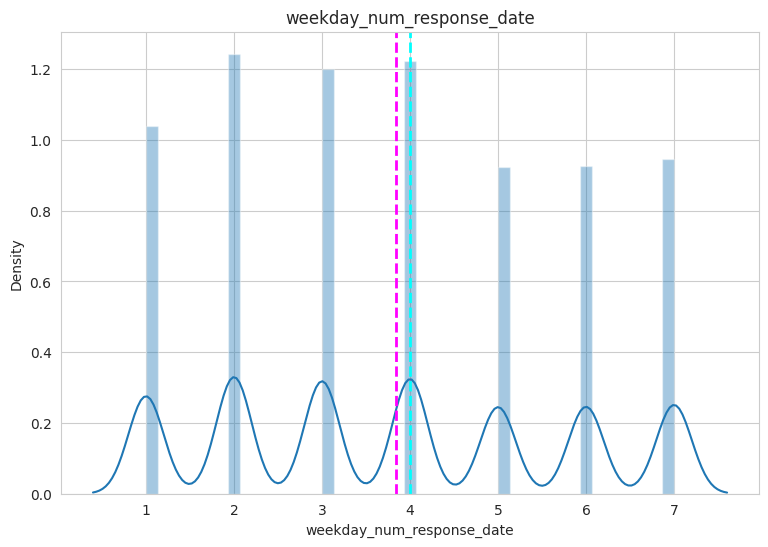

In [59]:
# Visualizing code of hist plot for each columns to know the data distibution
for col in df.loc[:,symmetric_feature]:
  fig=plt.figure(figsize=(9,6))
  ax=fig.gca()
  feature= (df[col])
  sns.distplot(df[col])
  ax.axvline(feature.mean(),color='magenta', linestyle='dashed', linewidth=2)
  ax.axvline(feature.median(),color='cyan', linestyle='dashed', linewidth=2)
  ax.set_title(col)
plt.show()

### 7. Data Scaling


In [60]:
# Checking the data
df.head()

,Item_price,connected_handling_time,CSAT Score,Customer_City_frequency,channel_name_Email,channel_name_Inbound,channel_name_Outcall,category_App/website,category_Cancellation,category_Feedback,...,Sub-category_Unable to Login,Sub-category_Unable to track,Sub-category_Wallet related,Sub-category_Warranty related,Sub-category_Wrong,Sub-category_e-Gift Voucher,Response_Time_seconds,day_number_order_date,day_number_response_date,weekday_num_response_date
0,2.365091,462.400826,5,0.809596,False,False,True,False,False,False,...,False,False,False,False,False,False,2.592410,1.732051,1.0,2
1,2.365091,462.400826,5,0.809596,False,False,True,False,False,False,...,False,False,False,False,False,False,1.819272,1.732051,1.0,2
2,2.365091,462.400826,5,0.809596,False,True,False,False,False,False,...,False,False,False,False,False,False,2.455114,1.732051,1.0,2
3,2.365091,462.400826,5,0.809596,False,True,False,False,False,False,...,False,False,False,False,False,False,2.426038,1.732051,1.0,2
4,2.365091,462.400826,5,0.809596,False,True,False,False,True,False,...,False,False,False,False,False,False,1.819272,1.732051,1.0,2


In [61]:
#Dropping the target variable for Y
y=df['CSAT Score']
df.drop(columns=['CSAT Score'],inplace=True)

In [62]:
# Select only the numerical columns from df
numerical_columns = df.select_dtypes(include=['number']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to the numerical columns
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Display the scaled DataFrame
df.head()

,Item_price,connected_handling_time,Customer_City_frequency,channel_name_Email,channel_name_Inbound,channel_name_Outcall,category_App/website,category_Cancellation,category_Feedback,category_Offers & Cashback,...,Sub-category_Unable to Login,Sub-category_Unable to track,Sub-category_Wallet related,Sub-category_Warranty related,Sub-category_Wrong,Sub-category_e-Gift Voucher,Response_Time_seconds,day_number_order_date,day_number_response_date,weekday_num_response_date
0,-0.09226,0.0,0.484955,False,False,True,False,False,False,False,...,False,False,False,False,False,False,0.363236,-0.106597,-2.735145,-0.94492
1,-0.09226,0.0,0.484955,False,False,True,False,False,False,False,...,False,False,False,False,False,False,-0.590667,-0.106597,-2.735145,-0.94492
2,-0.09226,0.0,0.484955,False,True,False,False,False,False,False,...,False,False,False,False,False,False,0.193840,-0.106597,-2.735145,-0.94492
3,-0.09226,0.0,0.484955,False,True,False,False,False,False,False,...,False,False,False,False,False,False,0.157965,-0.106597,-2.735145,-0.94492
4,-0.09226,0.0,0.484955,False,True,False,False,True,False,False,...,False,False,False,False,False,False,-0.590667,-0.106597,-2.735145,-0.94492


In [63]:
numerical_columns

Index(['Item_price', 'connected_handling_time', 'Customer_City_frequency',
       'Response_Time_seconds', 'day_number_order_date',
       'day_number_response_date', 'weekday_num_response_date'],
      dtype='object')

### 8. Data Splitting


In [64]:
# Extract the target variable
# The target variable 'CSAT Score' was already extracted into the 'y' variable
# in a previous step. We just need to reshape it for the OneHotEncoder.
y_reshaped = y.values.reshape(-1, 1)

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the target variable
y_one_hot = encoder.fit_transform(y_reshaped)

# Convert to pandas DataFrame
y_one_hot_df = pd.DataFrame(y_one_hot, columns=[f'class_{int(i)}' for i in range(y_one_hot.shape[1])])

In [65]:
 # splitting training and test data into 80:20 ratio

X_train, X_test, y_train, y_test = train_test_split(df,y_one_hot_df, test_size = 0.2, random_state = 0)

# describes info about train and test set
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

Number transactions X_train dataset:  (68725, 144)
Number transactions y_train dataset:  (68725, 5)
Number transactions X_test dataset:  (17182, 144)
Number transactions y_test dataset:  (17182, 5)


### 9. Handling Imbalanced Dataset


class_0  class_1  class_2  class_3  class_4
0.0      0.0      0.0      0.0      1.0        47741
                           1.0      0.0         8980
1.0      0.0      0.0      0.0      0.0         8941
0.0      0.0      1.0      0.0      0.0         2047
         1.0      0.0      0.0      0.0         1016
Name: count, dtype: int64
 


<Axes: ylabel='count'>

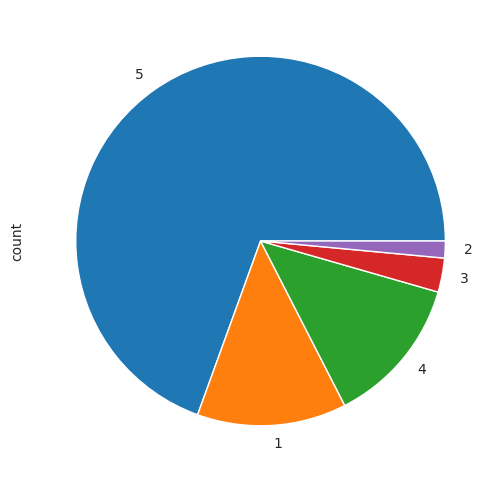

In [66]:
#  Visualizing Dependant Column Value Counts
print(y_train.value_counts())
print(" ")
# Dependant Variable Column Visualization
y_train.value_counts().plot(kind='pie',
                              figsize=(15,6),
                               labels=['5','1','4','3','2'])

Class imbalance is an important consideration in supervised machine learning classification problems, particularly when the target variable contains two or more classes with significantly different numbers of observations.

A dataset is considered balanced when the classes have approximately equal representation. For example, in a binary classification problem, a 50:50 distribution means that both classes contain roughly the same number of observations. A small degree of imbalance, such as 60:40, generally does not cause significant problems for many machine learning algorithms. However, when the imbalance becomes substantial, such as 90:10, the model may become biased toward the majority class.

In our project, the target variable has an approximate 75:25 class distribution, indicating a significant class imbalance. This creates a risk that the model may learn predominantly from the majority class and consequently predict the majority class more frequently, while performing poorly on the minority class.

Therefore, class balancing should be considered before model training. Techniques such as oversampling the minority class, undersampling the majority class, or using class weights can be applied to reduce the impact of class imbalance. The effectiveness of the chosen approach should then be evaluated using appropriate metrics such as precision, recall, F1-score, and a confusion matrix, rather than relying only on overall accuracy.

In [67]:
# Convert features to float32 (reduces memory usage)
X_train = X_train.astype('float32')

# Convert one-hot encoded labels back to a single column
if isinstance(y_train, pd.DataFrame):
    y_series = y_train.idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))  # Extract numeric labels
else:
    y_series = y_train


# Get the count for each class before SMOTE
class_counts = y_series.value_counts()
majority_count = class_counts.max()
print("Majority class count:", majority_count)

# Create a sampling strategy that balances all classes to the majority count
smote_strategy = {cls: majority_count for cls in class_counts.index if cls != class_counts.idxmax()}

print("SMOTE strategy for balancing:", smote_strategy)

# Apply SMOTE with the balancing strategy
sm = SMOTE(sampling_strategy=smote_strategy, random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_series)



# Print dataset info
print("\nFinal Dataset Sizes:")
print("X_train:", X_train_resampled.shape)
print("y_train:", y_train_resampled.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Majority class count: 47741
SMOTE strategy for balancing: {3: 47741, 0: 47741, 2: 47741, 1: 47741}

Final Dataset Sizes:
X_train: (238705, 144)
y_train: (238705,)
X_test: (17182, 144)
y_test: (17182, 5)


In [68]:
# Print count of each class in the resampled training data
class_counts_resampled = pd.Series(y_train_resampled).value_counts()
print("Class counts after SMOTE:")
print(class_counts_resampled)


Class counts after SMOTE:
4    47741
2    47741
0    47741
3    47741
1    47741
Name: count, dtype: int64


In [69]:
#Converting the target variable train data shape that of test data shape

# Extract the target variable
y = y_train_resampled.values.reshape(-1, 1)

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the target variable
y_one_hot = encoder.fit_transform(y)

# Convert y_train_resampled_one_hot back to DataFrame for consistency
y_train_resampled_df = pd.DataFrame(y_one_hot, columns=[f'class_{int(i)}' for i in range(y_one_hot.shape[1])])

class_0  class_1  class_2  class_3  class_4
0.0      0.0      0.0      0.0      1.0        47741
                           1.0      0.0        47741
                  1.0      0.0      0.0        47741
         1.0      0.0      0.0      0.0        47741
1.0      0.0      0.0      0.0      0.0        47741
Name: count, dtype: int64
 


<Axes: ylabel='count'>

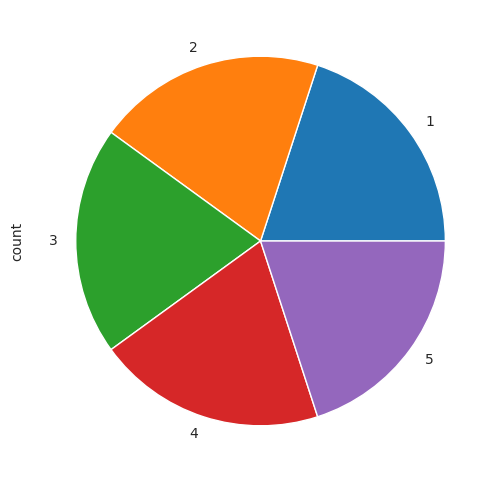

In [70]:
# Visualizing Dependant Column Value Counts after modification
print(y_train_resampled_df.value_counts())
print(" ")
# Dependant Variable Column Visualization
y_train_resampled_df.value_counts().plot(kind='pie',
                              figsize=(15,6),
                               labels=['1','2','3','4','5']


                              )

The dataset has an approximately 75:25 class distribution, indicating a significant imbalance between the majority and minority classes. If this imbalance is not addressed, a machine learning model may become biased toward the majority class and may not learn sufficient patterns from the minority class.

To address this issue, I used SMOTE (Synthetic Minority Over-sampling Technique) to balance the training data.

SMOTE is an oversampling technique designed to address class imbalance in supervised machine learning. Unlike simple random oversampling, which duplicates existing minority-class observations, SMOTE creates new synthetic minority-class samples based on existing minority observations. It generates these samples by selecting a minority-class observation and creating new points along the line segments between that observation and its nearest minority-class neighbors.

This allows the minority class to have greater representation in the training data without simply duplicating existing records. As a result, the model gets more opportunities to learn the characteristics and patterns of the minority class.

In [71]:
# Describe info about train and test set
print("Number of transactions in X_train dataset: ", X_train_resampled.shape)
print("Number of transactions in y_train dataset: ", y_train_resampled_df.shape)
print("Number of transactions in X_test dataset: ", X_test.shape)
print("Number of transactions in y_test dataset: ", y_test.shape)

Number of transactions in X_train dataset:  (238705, 144)
Number of transactions in y_train dataset:  (238705, 5)
Number of transactions in X_test dataset:  (17182, 144)
Number of transactions in y_test dataset:  (17182, 5)


###  **ML Model Implementation**

## Ensuring the target labels in the correct format.


In [72]:
# Ensure target labels are numerical and feature arrays are float
y_train_numerical = y_train_resampled_df.astype(int)
y_test_numerical = y_test.astype(int)

# Convert DataFrames to NumPy arrays without forcing another full-size copy
X_train_array = X_train_resampled.to_numpy(dtype=np.float32, copy=False)
X_test_array = X_test.to_numpy(dtype=np.float32, copy=False)

# Ensure target labels are numpy arrays
y_train_array = np.array(y_train_numerical)
y_test_array = np.array(y_test_numerical)

In [73]:
# Get input dimensions
input_dim = X_train.shape[1]
num_classes = len(np.unique(y))
input_dim ,num_classes

(144, 5)

## Define the ANN Model

In [74]:
# Defining the learning scheduler

def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [75]:
# Moderate regularization so the network can learn from the encoded features
dropout_rate = 0.2

neural_classifier = Sequential(
    [
        Dense(128, activation="relu", kernel_regularizer=l2(1e-4), input_dim=X_train.shape[1]),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(96, activation="relu", kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(num_classes, activation="softmax")
    ]
)

neural_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,677 (158.89 KB)

 Trainable params: 40,037 (156.39 KB)

 Non-trainable params: 640 (2.50 KB)

## Define and Initialize the Keras Classifier model

In [76]:
### Initialize Model

scikeras_classifier = KerasClassifier(model=neural_classifier,
                                    optimizer="adam",
                                    loss=keras.losses.categorical_crossentropy,
                                    batch_size=512,
                                    epochs=30,
                                    metrics=['accuracy'],
                                    random_state=42,
                                    warm_start=False
                          )

##  Initialize StratifiedKFold Cross Validation (no. of folds=3)

In [77]:
# Define number of folds
n_folds = 3

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)


## Performing 3-fold cross validation and training the ANN deep learning model

In [78]:
# Lists to store train and test accuracies
train_accuracies = []
test_accuracies = []

# Lists to store train and test accuracies for visualization
history_list = []

# Perform 3-fold cross-validation
for train_index, test_index in skf.split(X_train_array, np.argmax(y_train_array, axis=1)):
    X_train_fold, X_test_fold = X_train_array[train_index], X_train_array[test_index]
    y_train_fold, y_test_fold = y_train_array[train_index], y_train_array[test_index]

    # Define EarlyStopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    # Define LearningRateScheduler callback
    lr_scheduler = LearningRateScheduler(scheduler)

    # Fit the model with early stopping and learning rate scheduler
    scikeras_classifier.fit(X_train_fold, y_train_fold,
              validation_data=(X_test_fold, y_test_fold),
              callbacks=[early_stopping, lr_scheduler],
              verbose=1)

    # Append the history for visualization later
    history_list.append(scikeras_classifier.history_)

    # Evaluate the model on train data
    train_accuracy = scikeras_classifier.score(X_train_fold, y_train_fold)
    train_accuracies.append(train_accuracy)

    # Evaluate the model on test data
    test_accuracy = scikeras_classifier.score(X_test_fold, y_test_fold)
    test_accuracies.append(test_accuracy)

    # Train metric
    y_pred_tr = scikeras_classifier.predict(X_train_fold)
    y_pred_classes_tr = np.argmax(y_pred_tr, axis=1)
    y_test_classes_tr = np.argmax(y_train_fold, axis=1)

    # Test Metric
    y_pred = scikeras_classifier.predict(X_test_fold)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test_fold, axis=1)

    print("Train Accuracy:", accuracy_score(y_test_classes_tr, y_pred_classes_tr))
    print("Test Accuracy:", accuracy_score(y_test_classes, y_pred_classes))
    print("Classification Report:\n", classification_report(y_test_classes, y_pred_classes))

Epoch 1/30
311/311 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2597 - loss: 1.7138 - val_accuracy: 0.2935 - val_loss: 1.5820
Epoch 2/30
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3191 - loss: 1.5533 - val_accuracy: 0.3725 - val_loss: 1.4777
Epoch 3/30
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3825 - loss: 1.4518 - val_accuracy: 0.4154 - val_loss: 1.3824
Epoch 4/30
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4259 - loss: 1.3658 - val_accuracy: 0.4735 - val_loss: 1.2694
Epoch 5/30
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4592 - loss: 1.2985 - val_accuracy: 0.5051 - val_loss: 1.2002
Epoch 6/30
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4840 - loss: 1.2485 - val_accuracy: 0.5356 - val_loss: 1.1325
Epoch 7/30
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5028 - loss: 1.2079 - val_accuracy: 0.5523 - val_loss: 1.0913
Epoch 8/30
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5155 - loss: 1.1800 - val_accuracy: 

In [79]:
# Evaluate the final CV-fold model once on the untouched, naturally imbalanced holdout
holdout_probabilities = scikeras_classifier.predict_proba(X_test_array)
holdout_predictions = np.argmax(holdout_probabilities, axis=1)
holdout_true = np.argmax(y_test_array, axis=1)

print("Untouched holdout accuracy:", accuracy_score(holdout_true, holdout_predictions))
print("Untouched holdout classification report:\n", classification_report(
    holdout_true,
    holdout_predictions,
    target_names=[str(int(value)) for value in encoder.categories_[0]],
    zero_division=0
))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Untouched holdout accuracy: 0.425328832499127
Untouched holdout classification report:
               precision    recall  f1-score   support

           0       0.27      0.37      0.31      2289
           1       0.02      0.05      0.03       267
           2       0.03      0.09      0.05       511
           3       0.14      0.27      0.19      2239
           4       0.75      0.49      0.59     11876

    accuracy                           0.43     17182
   macro avg       0.24      0.25      0.23     17182
weighted avg       0.58      0.43      0.48     17182



## Evaluating performance of ANN deep learning model


In [80]:
# Calculate mean train and validation accuracies across the SMOTE-balanced folds
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)

print("Mean CV Train Accuracy (SMOTE-balanced folds):", mean_train_accuracy)
print("Mean CV Validation Accuracy (SMOTE-balanced folds):", mean_test_accuracy)

Mean CV Train Accuracy (SMOTE-balanced folds): 0.6906536888862643
Mean CV Validation Accuracy (SMOTE-balanced folds): 0.6707066155518021



Final Metrics After 3-Fold Cross-Validation:
Mean Train Accuracy: 0.6907
Mean Test Accuracy: 0.6707

Per-Class Metrics:
Class 0: Precision: 0.6353, Recall: 0.5402, F1-score: 0.5839
Class 1: Precision: 0.8750, Recall: 0.9928, F1-score: 0.9302
Class 2: Precision: 0.7660, Recall: 0.9284, F1-score: 0.8394
Class 3: Precision: 0.5025, Recall: 0.4714, F1-score: 0.4864
Class 4: Precision: 0.5699, Recall: 0.4931, F1-score: 0.5287


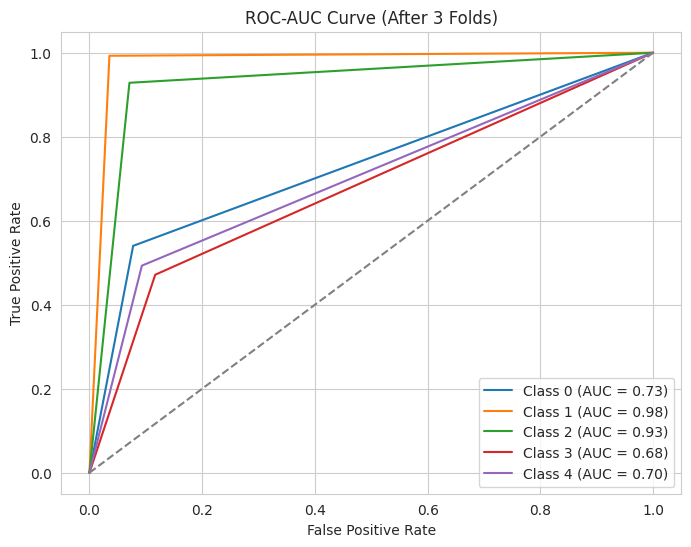

In [81]:
# Compute mean scores across 3 folds
mean_train_acc = np.mean(train_accuracies)
mean_test_acc = np.mean(test_accuracies)

# Print overall metrics
print("\nFinal Metrics After 3-Fold Cross-Validation:")
print(f"Mean Train Accuracy: {mean_train_acc:.4f}")
print(f"Mean Test Accuracy: {mean_test_acc:.4f}")

# Compute precision, recall, and F1-score for each class on test set
precision, recall, f1, _ = precision_recall_fscore_support(y_test_classes, y_pred_classes, average=None)

# Print per-class metrics
print("\nPer-Class Metrics:")
for i in range(len(precision)):
    print(f"Class {i}: Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1-score: {f1[i]:.4f}")

# Compute and plot ROC-AUC curve (One-vs-Rest for multi-class)
y_test_bin = label_binarize(y_test_classes, classes=np.unique(y_test_classes))
y_pred_bin = label_binarize(y_pred_classes, classes=np.unique(y_test_classes))

n_classes = y_test_bin.shape[1]
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve (After 3 Folds)")
plt.legend()
plt.show()


### **Model Evaluation & Interpretation**  
The trained Artificial Neural Network (ANN) model demonstrates good overall predictive performance, achieving a mean training accuracy of **69.07%** and a mean test accuracy of **67.07%**. The relatively small difference between training and test accuracy indicates that the model generalizes reasonably well to unseen data and does not show a substantial indication of overfitting based on accuracy alone.

The per-class evaluation provides additional insight into the model's classification performance. Class 1 and Class 2 show excellent discriminative performance, with AUC scores of **0.98** and **0.93**, respectively, indicating that the model can distinguish these classes very effectively. Class 0 also demonstrates good performance with an AUC of **0.73**.

However, performance is comparatively lower for Class 3 and Class 4, with AUC scores of 0.68 and 0.70, respectively. In particular, the lower AUC for Class 3 indicates that the model has greater difficulty distinguishing this class from the others. This may be associated with factors such as limited representation of the class, overlapping feature patterns, or similarities between satisfaction categories.

Although the model performs reasonably well overall, its performance could potentially be improved through feature engineering and selection, appropriate class-balancing strategies such as SMOTE, and hyperparameter tuning. Model evaluation should also consider metrics such as precision, recall, F1-score, confusion matrix, and per-class AUC, rather than relying solely on overall accuracy.

Overall, the ANN model provides a useful foundation for predicting customer satisfaction from customer interaction data and demonstrates the potential of deep learning to support data-driven analysis and improvements in e-commerce customer service.

## Conclusion

This project focused on predicting Customer Satisfaction (CSAT) scores for Shopzilla using a Deep Learning Artificial Neural Network (ANN). The complete machine learning workflow, from data preprocessing and feature engineering to model development, validation, evaluation, and business interpretation, was implemented.

1. **Dataset**:
The project used customer interaction data containing information about support channels, issue categories, customer feedback, order details, product information, agent attributes, handling time, and CSAT scores.
2. **Data Preprocessing**:
The data was prepared for ANN modeling by handling missing values, performing feature engineering, transforming categorical variables, and normalizing numerical features.
3. **Class Imbalance**:
The target variable showed an imbalanced class distribution. SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data to increase representation of the minority class and reduce the potential bias toward the majority class.
4. **Model Development**:
An Artificial Neural Network (ANN) classification model was developed to learn patterns in customer interaction data and predict CSAT categories.
5. **Cross-Validation**:
3-fold cross-validation was used to assess model performance across different subsets of the training data and provide a more robust estimate of its generalization performance.
6. **Overall Model Performance**:
The model achieved a mean training accuracy of **69.07%** and a mean test accuracy of **67.07%**. The relatively small difference between training and test accuracy suggests reasonable generalization, although accuracy alone is not sufficient to fully evaluate performance in an imbalanced multi-class problem.
7. **Per-Class Performance**:
The model demonstrated strong discriminative performance for **Class 1 (AUC = 0.98) and Class 2 (AUC = 0.93). Class 0 (AUC = 0.73) and Class 4 (AUC = 0.70)** showed good-to-moderate performance, while **Class 3 (AUC = 0.68)** was more difficult for the model to distinguish. This indicates that additional improvements may be required for certain satisfaction categories.
8. **Model Evaluation**:
Model performance was assessed using multiple evaluation measures, including precision, recall, F1-score, confusion matrix, and ROC-AUC, providing a broader view of classification performance across the different CSAT classes.
9. **Business Insights**:
Exploratory data analysis and model results provided insights into patterns within customer interactions, including differences across issue categories, service channels, handling times, and other customer-service attributes. These insights can help identify areas where customer service processes may require further investigation and improvement.
10. **Business Application**:
The trained model can serve as a foundation for predicting CSAT scores for new customer interactions. Such predictions could support customer-service teams in monitoring satisfaction patterns, identifying potentially dissatisfied customers, and improving service processes.
